# Notebook 05: Model Evaluation

## Objective

This notebook evaluates all trained machine learning models using various performance metrics.

The following models are compared:

- Logistic Regression
- Decision Tree
- Random Forest
- XGBoost

Evaluation Metrics:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC
- Confusion Matrix
- ROC Curve
- Precision-Recall Curve

The best performing model will be selected for deployment in the predictive maintenance dashboard.


In [1]:
import joblib
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

In [3]:
processed_data = pd.read_csv(
    "../dataset/ai4i2020_processed.csv"
)

processed_data.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,Temperature Difference,Mechanical Power,Wear Rate,Thermal Stress
0,2,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,10.5,66382.8,0.000000,449.40
1,1,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,10.5,65190.4,0.002131,486.15
2,1,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,10.4,74001.2,0.003338,513.76
3,1,298.2,308.6,1433,39.5,7,0,0,0,0,0,0,10.4,56603.5,0.004885,410.80
4,1,298.2,308.7,1408,40.0,9,0,0,0,0,0,0,10.5,56320.0,0.006392,420.00


In [4]:
X = processed_data.drop("Machine failure", axis=1)

y = processed_data["Machine failure"]

In [5]:
X_train = joblib.load("../models/preprocessing/X_train.pkl")
X_test = joblib.load("../models/preprocessing/X_test.pkl")

y_train = joblib.load("../models/preprocessing/y_train.pkl")
y_test = joblib.load("../models/preprocessing/y_test.pkl")

In [6]:
lr = joblib.load("../models/trained_models/logistic_regression.pkl")

dt = joblib.load("../models/trained_models/decision_tree.pkl")

rf = joblib.load("../models/trained_models/random_forest.pkl")

xgb = joblib.load("../models/trained_models/xgboost.pkl")

In [7]:
models = {
    "Logistic Regression": lr,
    "Decision Tree": dt,
    "Random Forest": rf,
    "XGBoost": xgb
}

In [8]:
results = []

for name, model in models.items():

    predictions = model.predict(X_test)

    probabilities = model.predict_proba(X_test)[:,1]

    accuracy = accuracy_score(y_test, predictions)

    precision = precision_score(y_test, predictions)

    recall = recall_score(y_test, predictions)

    f1 = f1_score(y_test, predictions)

    roc = roc_auc_score(y_test, probabilities)

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1,
        roc
    ])

In [9]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"
    ]
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.9990,1.000000,0.970588,0.985075,0.974767
1,Decision Tree,0.9985,0.985075,0.970588,0.977778,0.985035
2,Random Forest,0.9990,1.000000,0.970588,0.985075,0.990409
3,XGBoost,0.9990,1.000000,0.970588,0.985075,0.995030


In [10]:
results_df = results_df.round(4)
results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.9990,1.0000,0.9706,0.9851,0.9748
1,Decision Tree,0.9985,0.9851,0.9706,0.9778,0.9850
2,Random Forest,0.9990,1.0000,0.9706,0.9851,0.9904
3,XGBoost,0.9990,1.0000,0.9706,0.9851,0.9950


In [11]:
results_df.to_csv(
    "../reports/model_evaluation_results.csv",
    index=False
)

print("Model evaluation results saved successfully!")

Model evaluation results saved successfully!


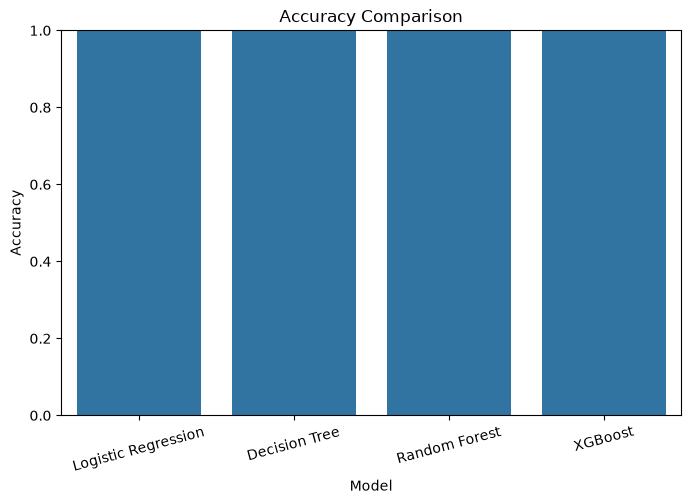

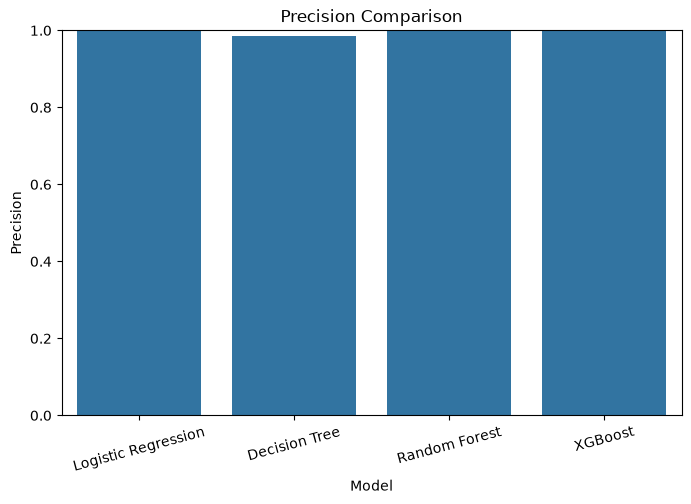

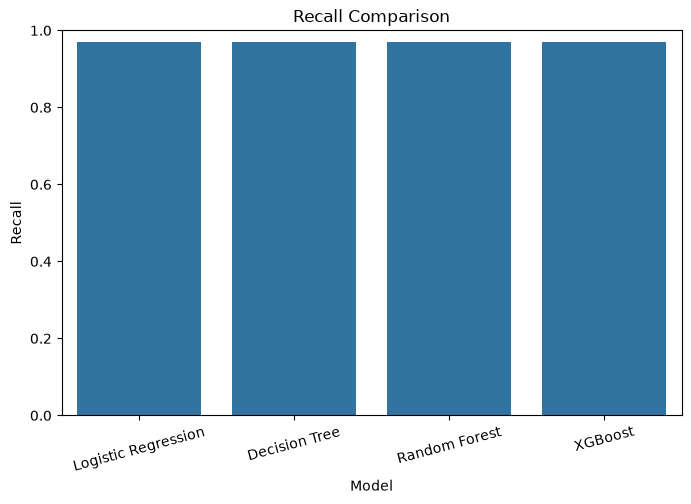

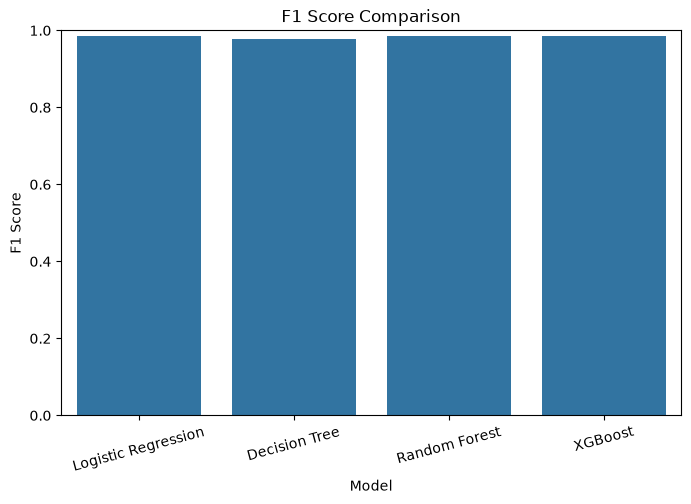

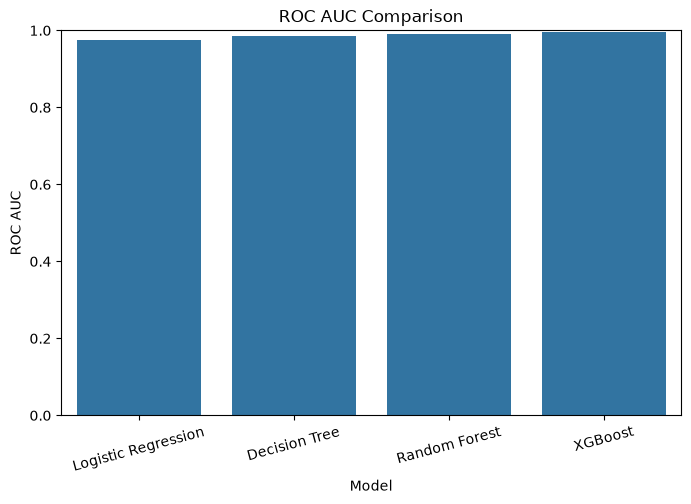

In [12]:
metrics = ["Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC"]

for metric in metrics:
    plt.figure(figsize=(8,5))
    
    sns.barplot(
        data=results_df,
        x="Model",
        y=metric
    )
    
    plt.title(f"{metric} Comparison")
    plt.xticks(rotation=15)
    plt.ylim(0, 1)
    plt.show()

In [13]:
for name, model in models.items():
    print("=" * 60)
    print(name)
    print("=" * 60)
    
    predictions = model.predict(X_test)
    
    print(classification_report(y_test, predictions))

Logistic Regression
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1932
           1       1.00      0.97      0.99        68

    accuracy                           1.00      2000
   macro avg       1.00      0.99      0.99      2000
weighted avg       1.00      1.00      1.00      2000

Decision Tree
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1932
           1       0.99      0.97      0.98        68

    accuracy                           1.00      2000
   macro avg       0.99      0.99      0.99      2000
weighted avg       1.00      1.00      1.00      2000

Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1932
           1       1.00      0.97      0.99        68

    accuracy                           1.00      2000
   macro avg       1.00      0.99      0.99      2000
weighted avg       1.00   

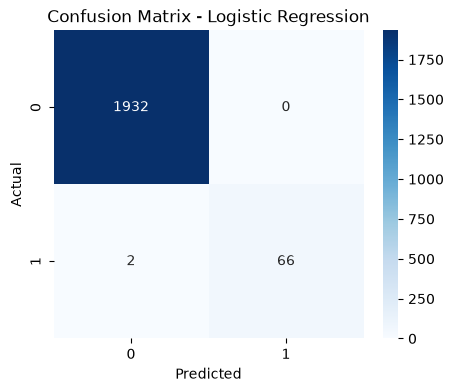

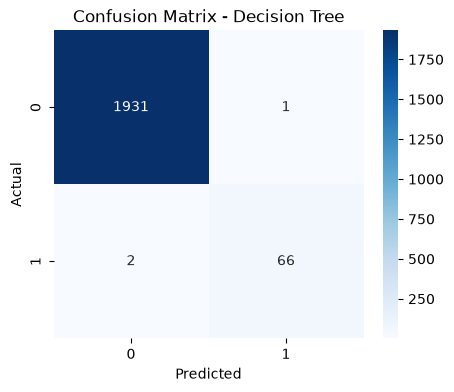

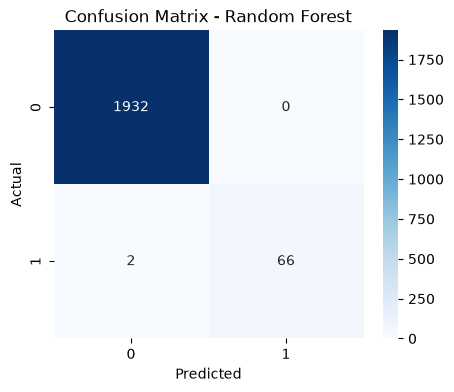

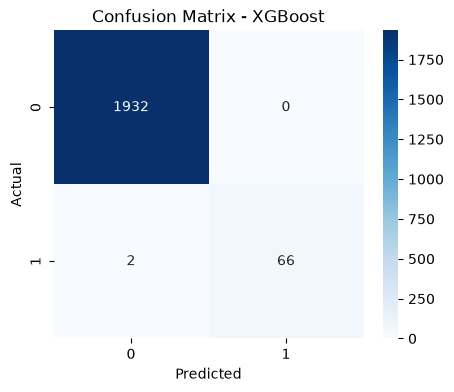

In [14]:
for name, model in models.items():
    predictions = model.predict(X_test)
    
    cm = confusion_matrix(y_test, predictions)
    
    plt.figure(figsize=(5,4))
    
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )
    
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

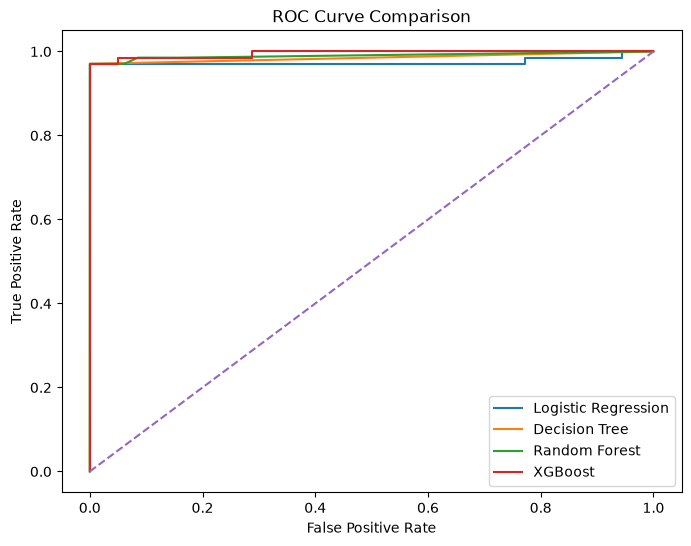

In [15]:
plt.figure(figsize=(8,6))

for name, model in models.items():
    probabilities = model.predict_proba(X_test)[:, 1]
    
    fpr, tpr, _ = roc_curve(y_test, probabilities)
    
    plt.plot(
        fpr,
        tpr,
        label=name
    )

plt.plot([0, 1], [0, 1], linestyle="--")

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

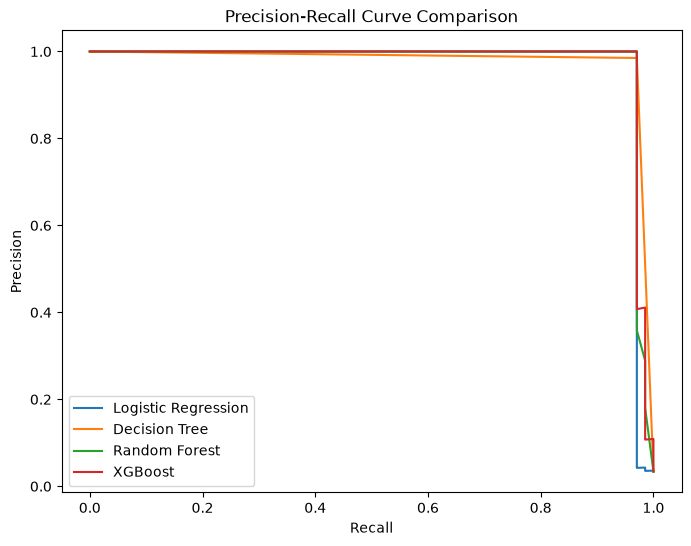

In [16]:
plt.figure(figsize=(8,6))

for name, model in models.items():
    probabilities = model.predict_proba(X_test)[:, 1]
    
    precision, recall, _ = precision_recall_curve(
        y_test,
        probabilities
    )
    
    plt.plot(
        recall,
        precision,
        label=name
    )

plt.title("Precision-Recall Curve Comparison")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.show()

In [17]:
best_model_row = results_df.sort_values(
    by="F1 Score",
    ascending=False
).iloc[0]

best_model_name = best_model_row["Model"]

print("Best Model Selected:", best_model_name)
best_model_row

Best Model Selected: Logistic Regression


Model        Logistic Regression
Accuracy                   0.999
Precision                    1.0
Recall                    0.9706
F1 Score                  0.9851
ROC AUC                   0.9748
Name: 0, dtype: object

In [18]:
joblib.dump(
    best_model_name,
    "../models/trained_models/best_model_name.pkl"
)

print("Best model name saved successfully!")

Best model name saved successfully!


In [19]:
feature_names = joblib.load(
    "../models/preprocessing/feature_names.pkl"
)

rf_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf.feature_importances_
})

rf_importance = rf_importance.sort_values(
    by="Importance",
    ascending=False
)

rf_importance

,Feature,Importance
7,HDF,0.217507
9,OSF,0.177750
8,PWF,0.128962
12,Mechanical Power,0.104847
6,TWF,0.101163
4,Torque [Nm],0.058841
3,Rotational speed [rpm],0.052752
13,Wear Rate,0.039901
11,Temperature Difference,0.035459
14,Thermal Stress,0.033767


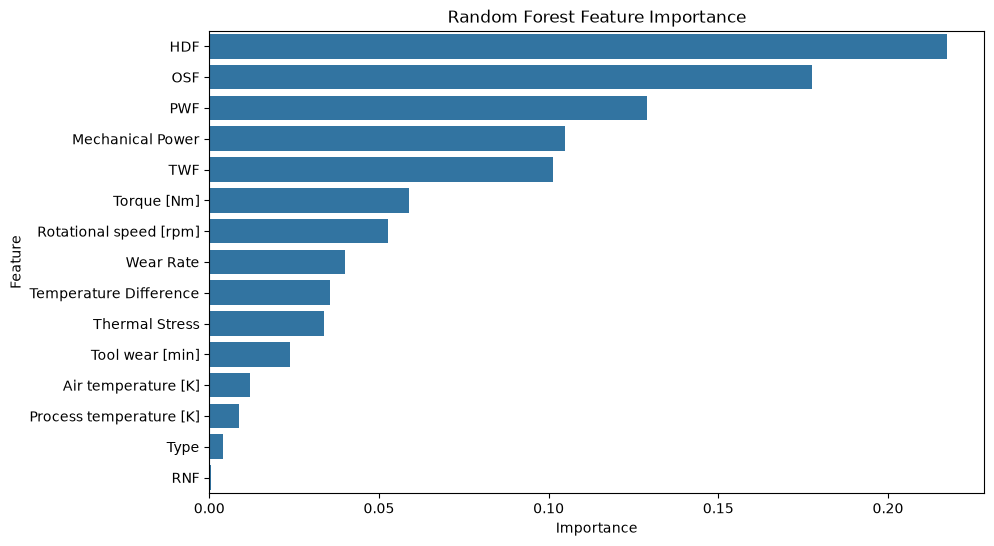

In [20]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=rf_importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")
plt.show()

In [21]:
rf_importance.to_csv(
    "../reports/random_forest_feature_importance.csv",
    index=False
)

print("Feature importance saved successfully!")

Feature importance saved successfully!


# Notebook Summary

✔ Loaded trained machine learning models

✔ Evaluated models using Accuracy, Precision, Recall, F1 Score, and ROC-AUC

✔ Generated confusion matrices for all models

✔ Compared ROC curves and Precision-Recall curves

✔ Selected the best model based on F1 Score

✔ Analyzed Random Forest feature importance

✔ Saved evaluation results for report and dashboard usage